# Netflix Movies & TV Shows Data Analysis

## Introduction
This project analyzes the Netflix dataset to understand trends in content type, genres, ratings, duration, and release patterns.

#Import necessary libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview
The dataset contains information about Netflix movies and TV shows including title, type, country, release year, rating, and duration.

#Loading the dataset


In [ ]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#To check the dataset information


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


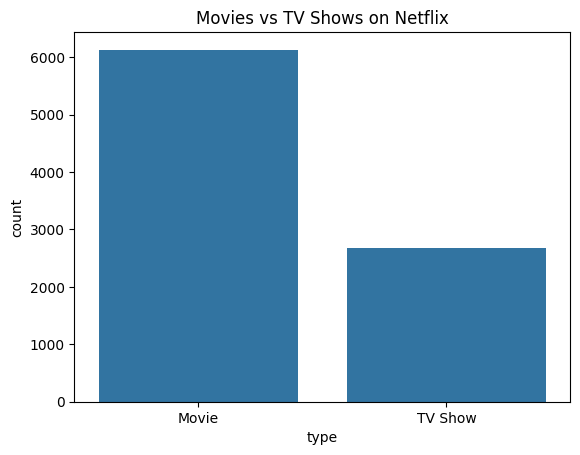

In [ ]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

## Data Cleaning
Missing values were handled and unnecessary data was cleaned. The duration column was converted into numeric format for analysis.

#Check missing values


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


#Top Countries Producing Netflix Content

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


#Graph


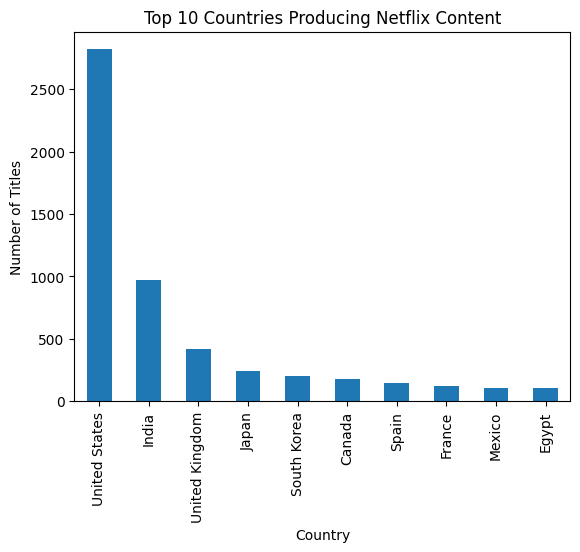

In [ ]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

#Content Released Over Years

In [ ]:
df['release_year'].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


#Graph

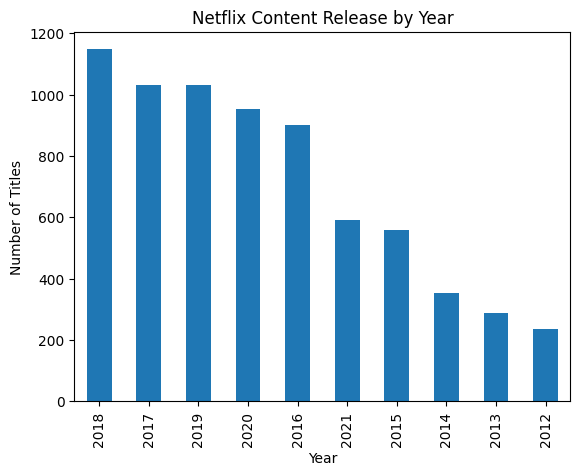

In [ ]:
df['release_year'].value_counts().head(10).plot(kind='bar')

plt.title("Netflix Content Release by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

#Most Common Genres

In [ ]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


#Graph

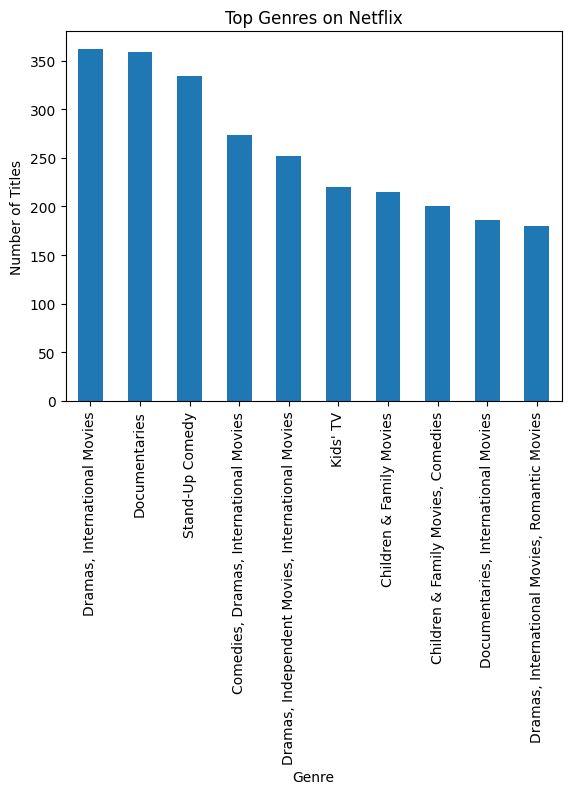

In [ ]:
df['listed_in'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.show()

#Rating Analysis

In [ ]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


#Graph


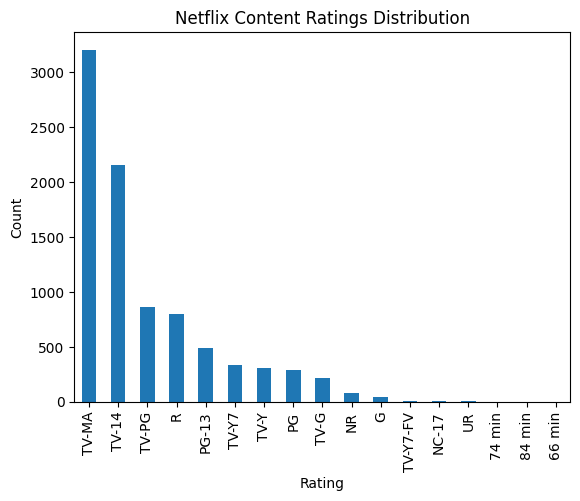

In [ ]:
import matplotlib.pyplot as plt

df['rating'].value_counts().plot(kind='bar')

plt.title("Netflix Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

#Movie Duration Analysis

In [ ]:
# Step 1: copy
movies = df[df['type'] == 'Movie'].copy()

# Step 2: convert to string first (VERY IMPORTANT)
movies['duration'] = movies['duration'].astype(str)

# Step 3: remove ' min'
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)

# Step 4: convert to numeric safely
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Step 5: remove NaN
movies = movies.dropna(subset=['duration'])

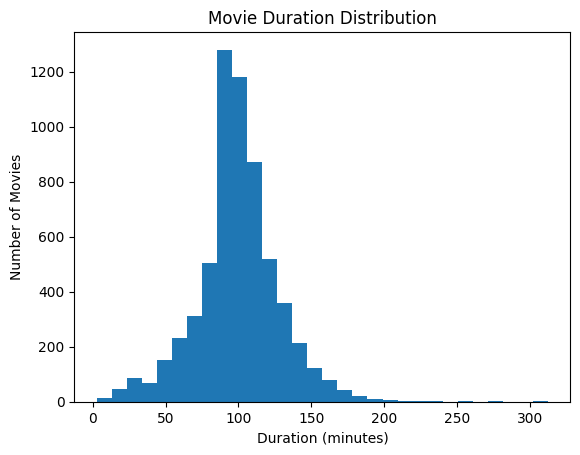

In [ ]:
movies['duration'].plot(kind='hist', bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

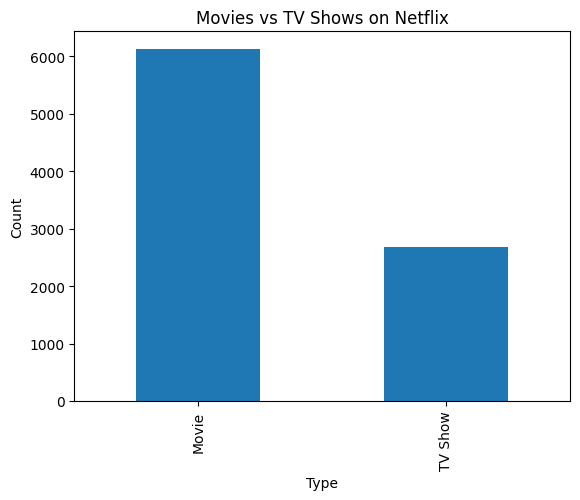

In [ ]:
df['type'].value_counts().plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

#Content Trend Over Years

In [ ]:
df['release_year'].value_counts().sort_index()


,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


#Graph

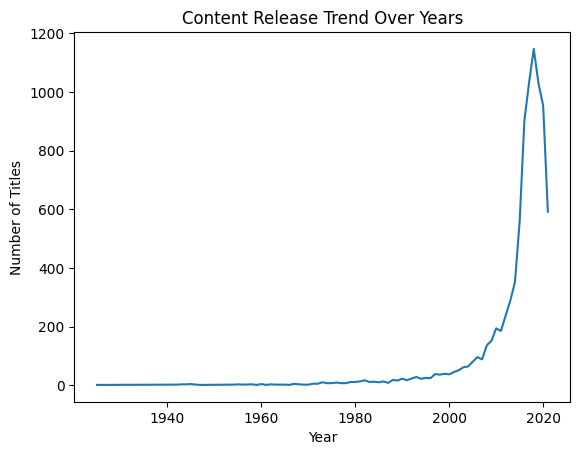

In [ ]:
df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Content Release Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

#Combine Movies vs TV Shows + Ratings

## Exploratory Data Analysis
Various visualizations were created to analyze patterns and trends in Netflix content.

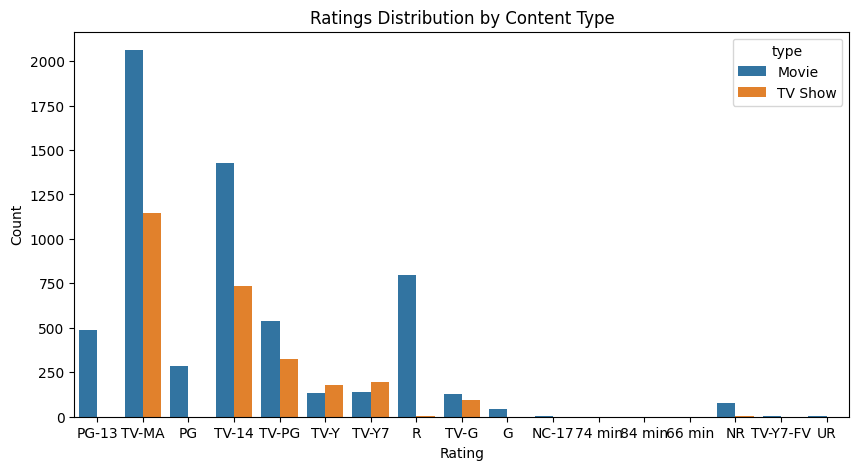

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', hue='type')

plt.title("Ratings Distribution by Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

#Top Genres

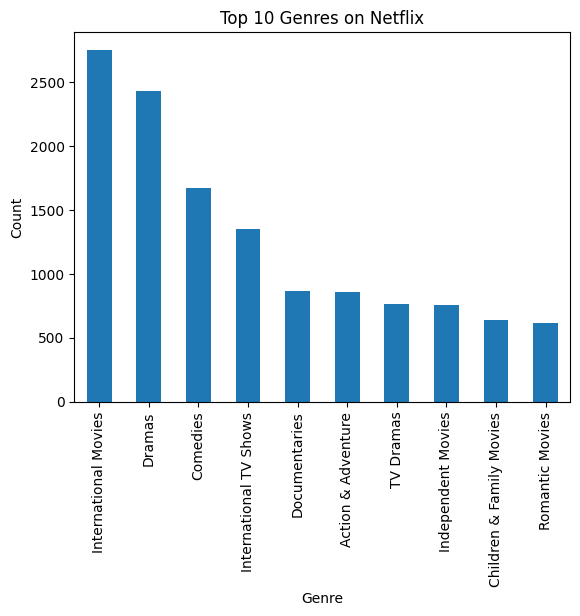

In [ ]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

## Key Insights

- Netflix has more Movies than TV Shows.
- Most content is rated TV-MA.
- USA produces the highest content.
- Content increased after 2015.
- Most movies are 80–120 minutes long.
- Drama and International genres are most common.

## Conclusion

This project highlights Netflix’s content trends and growth. The platform focuses heavily on movies and mature content, with a strong increase in content production in recent years.